## Today's Goals

- Build intuition for Fourier transforms (what the spectrum *means*)
- Interpret spectrograms (and why STFT is needed)
- Use frequency-domain filters to understand smoothing/edges
- Understand what "engineered features" are and why they still matter

## Why the Frequency Domain Shows Up Everywhere

**Audio applications:**

- Pitch detection and harmonics
- Noise removal
- Speech features (MFCCs, mel spectrograms)
- Spectrogram-based deep learning models

**Image applications:**

- Blur and sharpen as frequency filtering
- Periodic noise removal
- Texture analysis

**Deep learning connection:**

- CNNs behave like learned filter banks
- Spectrograms feed CNNs for audio tasks
- Understanding frequency helps debug models

# Signals as Functions Over Time

- A signal is just a function that changes with time (or space).


A **1D signal**:

$$
x(t): \mathbb{R} \rightarrow \mathbb{R}
$$

**Examples:**

- Audio waveform (pressure vs time)
- Sensor measurement
- Pixel intensity along a scanline

<!-- ### Instructor emphasis

> “Nothing fancy yet — a signal is just a curve.” -->

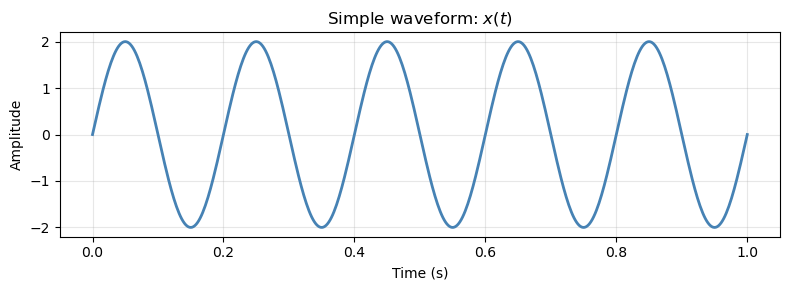

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simple waveform
t = np.linspace(0, 1, 500)
amplitude = 2
frequency = 5
x = amplitude * np.sin(2 * np.pi * frequency * t)  # 5 Hz sine wave

plt.figure(figsize=(8, 3))
plt.plot(t, x, color="steelblue", linewidth=2)
plt.title("Simple waveform: $x(t)$")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sine and Cosine Signals

Sine and cosine are the *simplest repeating patterns*.

- Sinusoids:
$$
\cos(\omega t), \quad \sin(\omega t)
$$

**Properties:**

- Smooth
- Periodic
- Defined by **amplitude**, **frequency**, **phase**

$$
A \cos(\omega t + \phi)
$$

**Components:**

- **Amplitude**: How high or low the wave is (magnitude)
- **Frequency**: How many times the wave repeats per second (cycles per second, or Hertz)
- **Phase**: Where the wave starts (initial offset / time shift)

<!-- ### Instructor emphasis

> “If something oscillates smoothly, sinusoids show up whether you ask for them or not.” -->


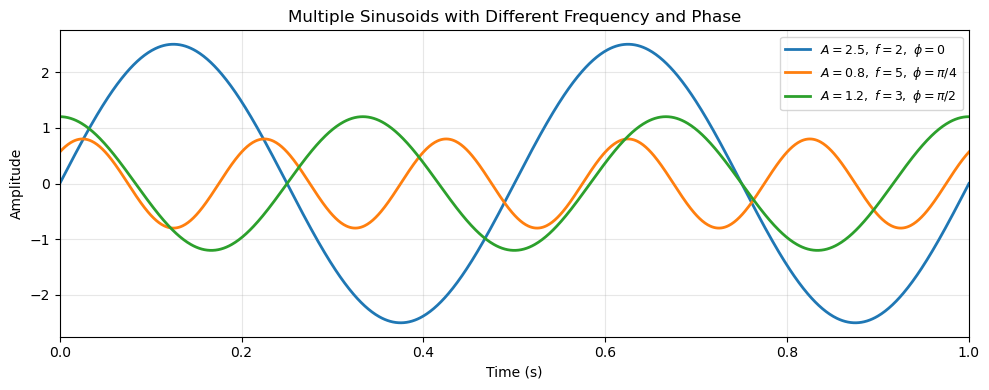

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Multiple sine waves with different frequencies and phases
t = np.linspace(0, 1, 1000)

waves = [
    {"A": 2.5, "f": 2, "phi": 0.0, "label": r"$A=2.5,\ f=2,\ \phi=0$"},
    {"A": 0.8, "f": 5, "phi": np.pi/4, "label": r"$A=0.8,\ f=5,\ \phi=\pi/4$"},
    {"A": 1.2, "f": 3, "phi": np.pi/2, "label": r"$A=1.2,\ f=3,\ \phi=\pi/2$"},
]

plt.figure(figsize=(10, 4))

for w in waves:
    x = w["A"] * np.sin(2 * np.pi * w["f"] * t + w["phi"])
    plt.plot(t, x, linewidth=2, label=w["label"])

plt.xlim(0, 1)
plt.title("Multiple Sinusoids with Different Frequency and Phase")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Phase Shift

Sine and cosine represent the **same oscillation**, just shifted in time.

Phase-shift relationship:

$$
\sin(\omega t) = \cos\left(\omega t - \frac{\pi}{2}\right)
$$

Using both lets us represent **any phase**:

$$
A \cos(\omega t) + B \sin(\omega t)
$$

<!-- ### Instructor emphasis

> “Cosine sets where the wave starts; sine adjusts the timing.” -->



In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# GIF settings
n_frames = 120
fps = 10
frames_dir = "./images/frames_sin_cos"
os.makedirs(frames_dir, exist_ok=True)

# Time axis
t = np.linspace(0, 2*np.pi, 1000)
sin_wave = np.sin(t)

# Phase shift as multiples of pi (back and forth)
phi_mult = np.linspace(-0.5, 0.5, n_frames//2)
phi_mult = np.concatenate([phi_mult, phi_mult[::-1]])
phase_shifts = phi_mult * np.pi  # actual phase

frame_files = []

for i, (m, phi) in enumerate(zip(phi_mult, phase_shifts)):
    cos_shifted = np.cos(t + phi)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(t, sin_wave, label=r'$\sin(\omega t)$', linewidth=2, color='blue')
    ax.plot(
        t, cos_shifted,
        label=rf'$\cos(\omega t + {m:.2f}\pi)$',
        linewidth=2, color='red', linestyle='--'
    )

    ax.set_title("Sine and Shifted Cosine (moving phase)")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{i:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    plt.close(fig)

# Build GIF
gif_path = "./images/sin_cos_phase_shift.gif"
with imageio.get_writer(gif_path, mode='I', fps=fps, loop=0) as writer:
    for frame_path in frame_files:
        image = imageio.imread(frame_path)
        writer.append_data(image)

# print(f"Saved GIF to {gif_path}")

# Cleanup frames
for frame_path in frame_files:
    os.remove(frame_path)
os.rmdir(frames_dir)

# print("Deleted frame images.")

![](./images/sin_cos_phase_shift.gif)

<!-- ## Phase Shift Visualization and Audio

Changing the **phase** shifts the waveform in time. For a **single pure tone**, a phase shift is just a time shift, so it usually **sounds the same**. For **multi‑component signals**, changing the **relative phase** between components changes the waveform shape and can affect timbre.

Below: the same tone with two different phase offsets (listen to confirm they sound the same). -->

In [ ]:
# TODO: add audio example where we change the phase of a single tone

# import numpy as np
# from IPython.display import Audio, display

# sr = 22050
# duration = 1.5
# f = 440

# # Same tone, different phase offsets
# phi_a = 0.0
# phi_b = np.pi / 2

# t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# tone_a = np.sin(2 * np.pi * f * t + phi_a)
# tone_b = np.sin(2 * np.pi * f * t + phi_b)

# print("Tone A (phase = 0)")
# display(Audio(tone_a, rate=sr))

# print("Tone B (phase = pi/2)")
# display(Audio(tone_b, rate=sr))

Tone A (phase = 0)


Tone B (phase = pi/2)


In [1]:
# # Two-tone signal: change relative phase
# from IPython.display import Audio, display
# import matplotlib.pyplot as plt

# sr = 22050
# duration = 1.5
# f1 = 440
# f2 = 880

# # Same magnitudes, different relative phase between components
# phi1 = 0.0
# phi2_a = 0.0
# phi2_b = np.pi / 2

# t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# tone1 = np.sin(2 * np.pi * f1 * t + phi1)
# tone2_a = 0.5 * np.sin(2 * np.pi * f2 * t + phi2_a)
# tone2_b = 0.5 * np.sin(2 * np.pi * f2 * t + phi2_b)

# signal_a = tone1 + tone2_a
# signal_b = tone1 + tone2_b

# print("Two-tone signal A (relative phase = 0)")
# display(Audio(signal_a, rate=sr))

# print("Two-tone signal B (relative phase = pi/2)")
# display(Audio(signal_b, rate=sr))

# # Plot a short segment to compare components + sum
# n_plot = 800
# fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# axes[0].plot(t[:n_plot], tone1[:n_plot], label="Tone 1 (440 Hz)")
# axes[0].plot(t[:n_plot], tone2_a[:n_plot], label="Tone 2 (880 Hz, phase=0)")
# axes[0].plot(t[:n_plot], signal_a[:n_plot], label="Sum", linewidth=2)
# axes[0].set_title("Signal A: relative phase = 0")
# axes[0].set_ylabel("Amplitude")
# axes[0].grid(alpha=0.3)
# axes[0].legend(loc="upper right")

# axes[1].plot(t[:n_plot], tone1[:n_plot], label="Tone 1 (440 Hz)")
# axes[1].plot(t[:n_plot], tone2_b[:n_plot], label="Tone 2 (880 Hz, phase=pi/2)")
# axes[1].plot(t[:n_plot], signal_b[:n_plot], label="Sum", linewidth=2)
# axes[1].set_title("Signal B: relative phase = pi/2")
# axes[1].set_xlabel("Time (s)")
# axes[1].set_ylabel("Amplitude")
# axes[1].grid(alpha=0.3)
# axes[1].legend(loc="upper right")

# plt.tight_layout()
# plt.show()

## Signals as Rotating Vectors

Sinusoids are projections of **rotating vectors**.


2D vector:

$$
\mathbf{v}(t)=\begin{bmatrix}\cos(\omega t) \\sin(\omega t)\end{bmatrix}
$$

As time increases, the vector rotates at angular speed $\omega$



<!-- ### Instructor emphasis

> “A sine wave is just a shadow of rotation.” -->



In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# GIF settings
n_frames = 120
fps = 10
frames_dir = "./images/frames_rotating_vector"
os.makedirs(frames_dir, exist_ok=True)

theta_vals = np.linspace(0, 2*np.pi, n_frames)
frame_files = []

# Precompute unit circle
theta_circle = np.linspace(0, 2*np.pi, 400)
circle_x = np.cos(theta_circle)
circle_y = np.sin(theta_circle)

for idx, theta in enumerate(theta_vals):
    x = np.cos(theta)
    y = np.sin(theta)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(circle_x, circle_y, 'gray', linewidth=1.5, alpha=0.6)

    # Rotating vector
    ax.arrow(0, 0, x*0.9, y*0.9, head_width=0.08, head_length=0.08,
             fc='blue', ec='blue', linewidth=2.5)

    # Projections
    ax.plot([0, x], [0, 0], 'r--', linewidth=2, label=r'$\cos(\omega t)$')
    ax.plot([x, x], [0, y], 'g--', linewidth=2, label=r'$\sin(\omega t)$')

    # Point
    ax.plot(x, y, 'bo', markersize=8)

    # Axes
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel('Real (x)')
    ax.set_ylabel('Imaginary (y)')
    ax.set_title("Rotating Vector on Unit Circle")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{idx:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    plt.close(fig)

# Build GIF with loop=0 (infinite loop)
gif_path = "./images/rotating_vector.gif"
with imageio.get_writer(gif_path, mode='I', fps=fps, loop=0) as writer:
    for frame_path in frame_files:
        image = imageio.imread(frame_path)
        writer.append_data(image)

# print(f"Saved GIF to {gif_path}")

# Cleanup frames
for frame_path in frame_files:
    os.remove(frame_path)
os.rmdir(frames_dir)

# print("Deleted frame images.")

![](./images/rotating_vector.gif)

## Rotation Matrix

Rotation is a linear transformation.


Rotation matrix:

$$
R(\theta)=\begin{bmatrix}\cos\theta & -\sin\theta \\ \sin\theta & \cos\theta\end{bmatrix}
$$

Repeated rotation = continuous oscillation

$$
\mathbf{v}_{t+1} = R(\Delta \theta)\mathbf{v}_t
$$


<!-- ### Instructor emphasis

> “Oscillations aren’t magic — they’re geometry.” -->



In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# GIF settings
n_steps = 64
theta_step = 2*np.pi / n_steps
frames_dir = "./images/frames_rotation"
os.makedirs(frames_dir, exist_ok=True)

frame_files = []

# Precompute circle
theta_circle = np.linspace(0, 2*np.pi, 400)
circle_x = np.cos(theta_circle)
circle_y = np.sin(theta_circle)

# Precompute rotation path
angles = np.arange(0, n_steps) * theta_step
x = np.cos(angles)
y = np.sin(angles)

for k in range(n_steps):
    fig, (ax_rot, ax_trace) = plt.subplots(1, 2, figsize=(10, 4))

    # ---- Left: rotating vector steps ----
    ax_rot.plot(circle_x, circle_y, color='gray', alpha=0.4)
    for i in range(k + 1):
        ax_rot.plot([0, x[i]], [0, y[i]], color='blue', alpha=0.25)

    # Current vector
    ax_rot.arrow(0, 0, x[k], y[k], head_width=0.05, head_length=0.05,
                 fc='blue', ec='blue', linewidth=2)

    ax_rot.set_aspect('equal')
    ax_rot.set_xlim(-1.2, 1.2)
    ax_rot.set_ylim(-1.2, 1.2)
    ax_rot.set_title("Repeated Rotation")
    ax_rot.set_xlabel("x")
    ax_rot.set_ylabel("y")
    ax_rot.grid(alpha=0.3)

    # ---- Right: trace of x-component ----
    ax_trace.plot(np.arange(k + 1), x[:k + 1], 'r-', linewidth=2, label='x-component')
    ax_trace.scatter(np.arange(k + 1), x[:k + 1], color='red', s=12)
    ax_trace.set_title("Trace of x-component → cosine")
    ax_trace.set_xlabel("Step (t)")
    ax_trace.set_ylabel("Value")
    ax_trace.set_xlim(0, n_steps)
    ax_trace.set_ylim(-1.2, 1.2)
    ax_trace.grid(alpha=0.3)

    plt.tight_layout()

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{k:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    plt.close(fig)

# Build GIF
gif_path = "./images/rotation_matrix_trace.gif"
with imageio.get_writer(gif_path, mode='I', fps=10, loop=0) as writer:
    for frame_path in frame_files:
        image = imageio.imread(frame_path)
        writer.append_data(image)

print(f"Saved GIF to {gif_path}")

# Cleanup frames
for frame_path in frame_files:
    os.remove(frame_path)
os.rmdir(frames_dir)

print("Deleted frame images.")

Saved GIF to ./images/rotation_matrix_trace.gif
Deleted frame images.


![](./images/rotation_matrix_trace.gif)

## Rotation Matrix Numerical Example

### Step 1: Start with a simple vector

$$
\mathbf{v} = \begin{bmatrix} 1 \\ 0\end{bmatrix}
$$

This vector points along the (x)-axis.

### Step 2: Choose a rotation angle

Rotate by $90 \degree$:

$$
\theta = \frac{\pi}{2}
$$

### Step 3: Write the rotation matrix

$$
R\left(\frac{\pi}{2}\right) = \begin{bmatrix} \cos\left(\frac{\pi}{2}\right) & -\sin\left(\frac{\pi}{2}\right) \\ \sin\left(\frac{\pi}{2}\right) & \cos\left(\frac{\pi}{2}\right) \end{bmatrix} = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix}
$$


### Step 4: Apply the rotation

$$
\mathbf{v}' = R \left(\frac{\pi}{2}\right)\mathbf{v} \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 1 \end{bmatrix}
$$


### Step 5: Interpret the result

- The vector rotated **counterclockwise**
- Length is preserved:

$$
|\mathbf{v}| = |\mathbf{v}'| = 1
$$

- Repeating this rotation produces continuous circular motion


<!-- ### Instructor emphasis (what to say out loud)

> “This matrix *is* rotation — no trig intuition required.
> Apply it repeatedly and you get oscillations.” -->

<!-- ### Optional closing line (foreshadowing)

> “A signal is what you see when you watch just one coordinate of a rotating vector.” -->


## How this relates to signals

Signals are combinations of rotations at different speeds.


- Different $\omega$ → different rotation speeds
- Signals = mixtures of rotating components
- Next step: *How do we measure those rotations?*

<!-- ### Instructor emphasis

> “Fourier is just asking: which rotations are hiding in this signal?” -->

<!-- ## One-sentence narrative for students

> **Signals are built from smooth oscillations, oscillations come from rotation, and rotation is linear algebra.** -->

# Fourier Transform Intuition (1D)

**Key ideas:**

- Any signal can be written as a sum of sinusoids
- Fourier transform tells you "how much of each frequency"
- Two parts: **magnitude** and **phase**

$$
x(t) = \sin(2\pi f_1 t) + \sin(2\pi f_2 t)
$$


### Decomposing a signal

- The Fourier Series decomposes functions into a sum of sine and cosine terms with differing frequencies and amplitudes
- The original function $f(t)$, is called the “real space representation” and is continuous

$$
f(t) = f_1(t) + f_2(t)
$$

$$
f_1(t) = 2\sin(2\pi (3)t)
$$

$$
f_2(t) = 5\sin(2\pi (1)t)
$$

### Fourier Series

$$
F(w) = A(f) \rightarrow (f_n, A_n) \in [(1,5), (3,2)]
$$

### What the Axes Mean

- **x-axis:** frequency (Hz); $f=\omega/2\pi$
- **y-axis:** magnitude $|X(f)|$ (energy/amplitude proxy)
- **phase:** $\angle X(f)$ tells time alignment/shift
    - *Magnitude says “how much”; phase says “when/how those frequencies line up” in time.*

We use `np.fft.rfft` to compute $X[k]$ and `np.fft.rfftfreq` to map bins to Hz.



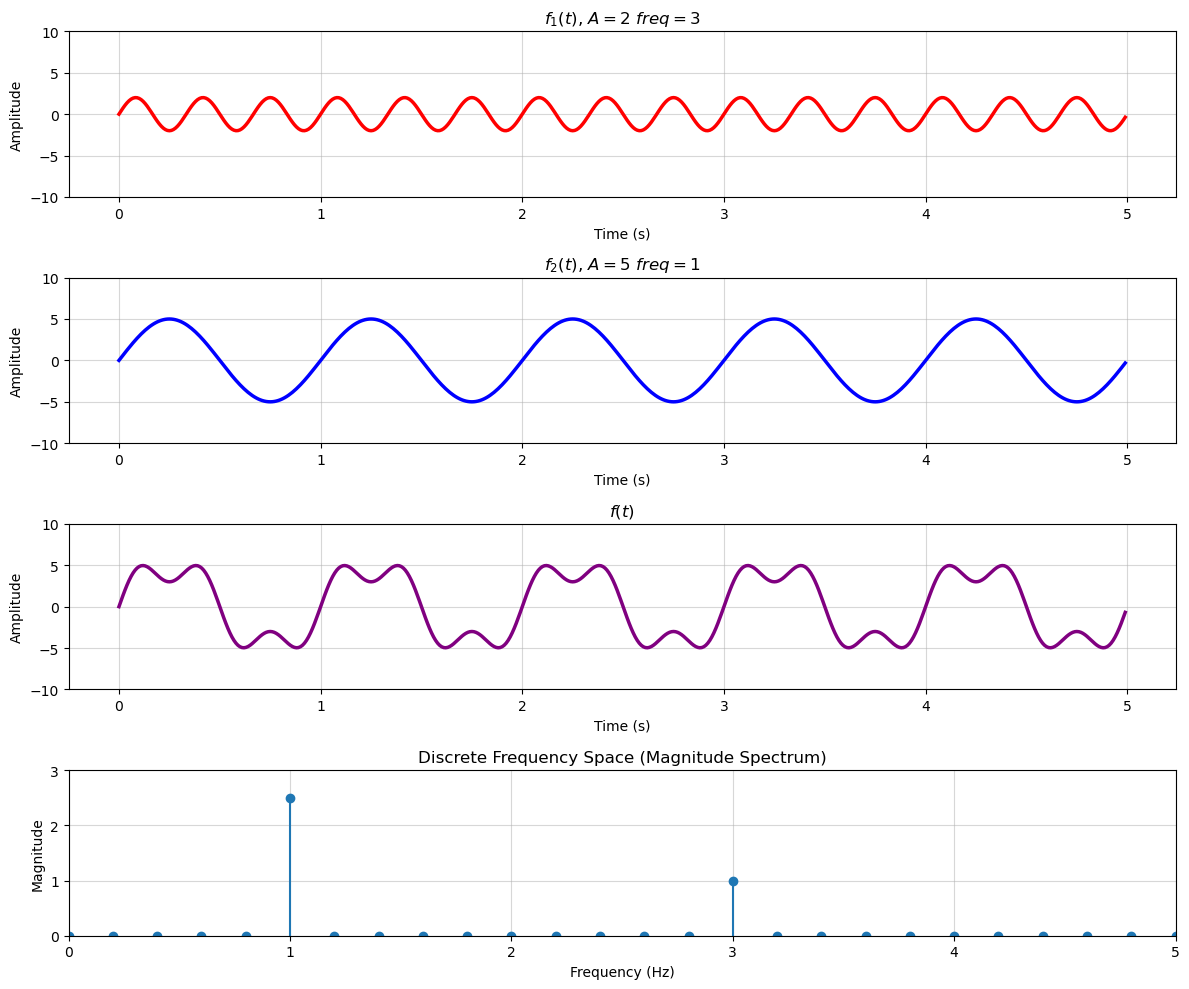

In [46]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

sr = 100
duration = 5
t = np.arange(0, duration, 1/sr)
amplitude = [2, 5]
frequency = [3, 1]
y_limits = [-10, 10]

# Define signals
s1 = amplitude[0] * np.sin(2 * np.pi * frequency[0] * t)
s2 = amplitude[1] * np.sin(2 * np.pi * frequency[1] * t)
s_sum = s1 + s2

# ---- Time domain plots ----
fig, ax = plt.subplots(nrows=4, figsize=(12, 10))
ax[0].plot(t, s1, linewidth=2.5, color="red")
ax[0].set_ylim(y_limits)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("$f_1(t)$, $A={}$ $freq={}$".format(amplitude[0], frequency[0]))
ax[0].grid(alpha=0.5)

ax[1].plot(t, s2, linewidth=2.5, color="blue")
ax[1].set_ylim(y_limits)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude")
ax[1].set_title("$f_2(t)$, $A={}$ $freq={}$".format(amplitude[1], frequency[1]))
ax[1].grid(alpha=0.5)

ax[2].plot(t, s_sum, linewidth=2.5, color="purple")
ax[2].set_ylim(y_limits)
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Amplitude")
ax[2].set_title("$f(t)$")
ax[2].grid(alpha=0.5)

# ---- Discrete frequency space (DFT) ----
N = len(s_sum)
X = np.fft.rfft(s_sum)
freqs = np.fft.rfftfreq(N, d=1/sr)
mag = np.abs(X) / N  # scale for amplitude

ax[3].stem(freqs, mag, basefmt=" ", linefmt="C0-", markerfmt="C0o")
ax[3].set_xlim(0, 5)  # zoom to relevant range
ax[3].set_ylim(0, 3)
ax[3].set_xlabel("Frequency (Hz)")
ax[3].set_ylabel("Magnitude")
ax[3].set_title("Discrete Frequency Space (Magnitude Spectrum)")
ax[3].grid(alpha=0.5)

plt.tight_layout()
plt.show()

Same plot as above but with "real world" frequencies

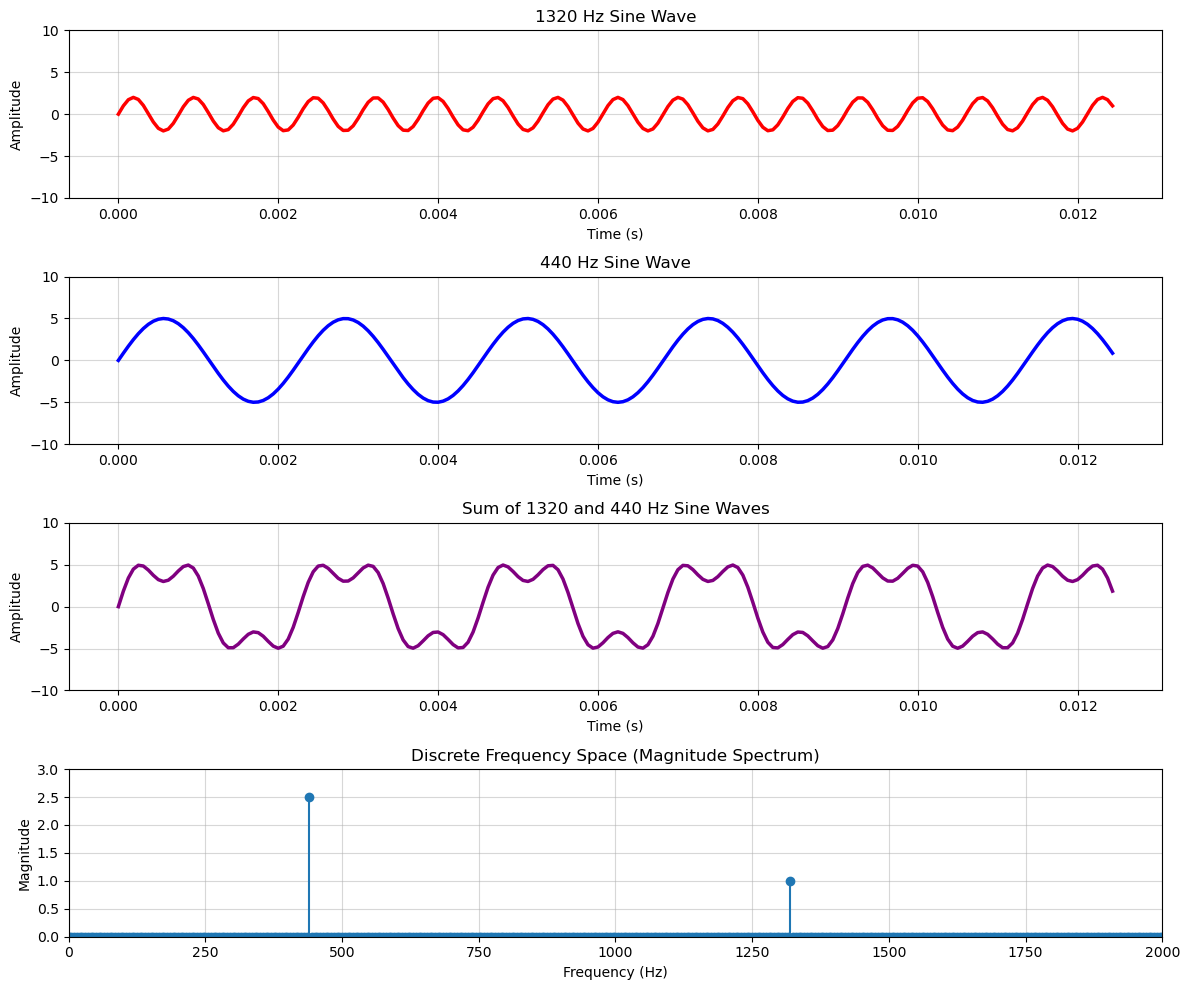

In [ ]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

sr = 16000
duration = 0.200  # 200ms
t = np.arange(0, duration, 1/sr)
amplitude = [2, 5]
frequency = [3*440, 1*440]
y_limits = [-10, 10]

# Define signals
s1 = amplitude[0] * np.sin(2 * np.pi * frequency[0] * t)
s2 = amplitude[1] * np.sin(2 * np.pi * frequency[1] * t)
s_sum = s1 + s2

# ---- Discrete frequency space (DFT) ----
N = len(s_sum)
X = np.fft.rfft(s_sum)
freqs = np.fft.rfftfreq(N, d=1/sr)
mag = np.abs(X) / N  # scale for amplitude

# ---- Time domain plots ----
fig, ax = plt.subplots(nrows=4, figsize=(12, 10))
ax[0].plot(t[:200], s1[:200], linewidth=2.5, color="red")
ax[0].set_ylim(y_limits)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title(f"{frequency[0]} Hz Sine Wave")
ax[0].grid(alpha=0.5)

ax[1].plot(t[:200], s2[:200], linewidth=2.5, color="blue")
ax[1].set_ylim(y_limits)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude")
ax[1].set_title(f"{frequency[1]} Hz Sine Wave")
ax[1].grid(alpha=0.5)

ax[2].plot(t[:200], s_sum[:200], linewidth=2.5, color="purple")
ax[2].set_ylim(y_limits)
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Amplitude")
ax[2].set_title(f"Sum of {frequency[0]} and {frequency[1]} Hz Sine Waves")
ax[2].grid(alpha=0.5)

# ---- Discrete frequency space (DFT) ----
N = len(s_sum)
X = np.fft.rfft(s_sum)
freqs = np.fft.rfftfreq(N, d=1/sr)
mag = np.abs(X) / N  # scale for amplitude

ax[3].stem(freqs, mag, basefmt=" ", linefmt="C0-", markerfmt="C0o")
ax[3].set_xlim(0, 2000)  # zoom to relevant range
ax[3].set_ylim(0, 3)
ax[3].set_xlabel("Frequency (Hz)")
ax[3].set_ylabel("Magnitude")
ax[3].set_title("Discrete Frequency Space (Magnitude Spectrum)")
ax[3].grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
print("440 Hz")
ipd.Audio(s1, rate=sr)

440 Hz


In [6]:
print("880 Hz")
ipd.Audio(s2, rate=sr)

880 Hz


In [5]:
print("Sum of 440 Hz and 880 Hz")
ipd.Audio(s_sum, rate=sr)

Sum of 440 Hz and 880 Hz


In [ ]:
# Continuous Fourier Transform Plot
# 
#  import IPython.display as ipd
# import matplotlib.pyplot as plt
# import numpy as np

# sr = 16000
# duration = 0.200  # 200ms
# t = np.arange(0, duration, 1/sr)
# amplitude = [2, 5]
# frequency = [3*440, 1*440]
# y_limits = [-10, 10]

# # Define signals
# s1 = amplitude[0] * np.sin(2 * np.pi * frequency[0] * t)
# s2 = amplitude[1] * np.sin(2 * np.pi * frequency[1] * t)
# s_sum = s1 + s2

# # ---- Continuous Fourier Transform (numerical approximation) ----
# f_max = 2000
# n_f = 2000
# f_grid = np.linspace(0, f_max, n_f)

# # X(f) = ∫ x(t) e^{-i2πft} dt
# Xf = np.array([
#     np.trapz(s_sum * np.exp(-2j * np.pi * f * t), t)
#     for f in f_grid
# ])
# mag = np.abs(Xf)

# # ---- Time domain plots ----
# fig, ax = plt.subplots(nrows=4, figsize=(12, 10))
# ax[0].plot(t[:200], s1[:200], linewidth=2.5, color="red")
# ax[0].set_ylim(y_limits)
# ax[0].set_xlabel("Time (s)")
# ax[0].set_ylabel("Amplitude")
# ax[0].set_title(f"{frequency[0]} Hz Sine Wave")
# ax[0].grid(alpha=0.5)

# ax[1].plot(t[:200], s2[:200], linewidth=2.5, color="blue")
# ax[1].set_ylim(y_limits)
# ax[1].set_xlabel("Time (s)")
# ax[1].set_ylabel("Amplitude")
# ax[1].set_title(f"{frequency[1]} Hz Sine Wave")
# ax[1].grid(alpha=0.5)

# ax[2].plot(t[:200], s_sum[:200], linewidth=2.5, color="purple")
# ax[2].set_ylim(y_limits)
# ax[2].set_xlabel("Time (s)")
# ax[2].set_ylabel("Amplitude")
# ax[2].set_title(f"Sum of {frequency[0]} and {frequency[1]} Hz Sine Waves")
# ax[2].grid(alpha=0.5)

# # ---- Continuous FT magnitude ----
# ax[3].plot(f_grid, mag, color="C0", linewidth=2)
# ax[3].set_xlim(0, 2000)
# ax[3].set_xlabel("Frequency (Hz)")
# ax[3].set_ylabel("|X(f)|")
# ax[3].set_title("Continuous Fourier Transform (Magnitude)")
# ax[3].grid(alpha=0.5)

# plt.tight_layout()
# plt.show()

## Euler's Formula

### Definition of $e^x$

- The exponential function is defined by its **power series** (this is the cleanest, most fundamental definition):

$$
e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!}
$$

- This definition works for **all real and complex** values of (x).

### Extend the definition to complex numbers

Now let $x = i \theta$, where $i = \sqrt{-1}$

Then by definition:

$$ e^{i\theta} = \sum_{n=0}^{\infty} \frac{(i\theta)^n}{n!} $$

Expand the first few terms:

$$
\begin{aligned}
e^{i\theta}
&= 1 + i\theta + \frac{(i\theta)^2}{2!} + \frac{(i\theta)^3}{3!} + \frac{(i\theta)^4}{4!} + \cdots \\
&= 1 + i\theta - \frac{\theta^2}{2!} - i\frac{\theta^3}{3!} + \frac{\theta^4}{4!} + \cdots
\end{aligned}
$$


### Group real and imaginary terms


**Real terms**

$$
1 - \frac{\theta^2}{2!} + \frac{\theta^4}{4!} - \frac{\theta^6}{6!} + \cdots
$$

**Imaginary terms**

$$
i\left(\theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \cdots\right)
$$

### Sine and Cosine Taylor Series

These two series are *exactly* the Taylor series definitions of cosine and sine:

$$
\cos\theta = \sum_{n=0}^{\infty} (-1)^n \frac{\theta^{2n}}{(2n)!} = 1 + \frac{\theta^2}{2!} - \frac{\theta^4}{4!} + \frac{\theta^6}{6!} - \frac{\theta^8}{8!} + \cdots  
$$

$$
\sin\theta = \sum_{n=0}^{\infty} (-1)^n \frac{\theta^{2n+1}}{(2n+1)!} = \theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \frac{\theta^7}{7!} + \cdots
$$

Substituting back:

$$
e^{i\theta} = \cos\theta + i\sin\theta
$$

### Euler’s Formula

This is **Euler’s formula**:

$$
\boxed{e^{i\theta} = \cos\theta + i\sin\theta}
$$


### Geometric interpretation (unit circle)

From Euler’s formula:

$$
|e^{i\theta}| = \sqrt{\cos^2\theta + \sin^2\theta} = 1
$$

So $e^{i\theta}$ traces the **unit circle** in the complex plane:

* Angle = $\theta$
* Radius = 1

This is why complex exponentials are perfect for:

* Fourier transforms
* Waves and oscillations
* Signal processing




In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ---- GIF parameters ----
n_frames = 120
thetas = np.linspace(0, 2*np.pi, n_frames)
frames_dir = "./images/frames_euler/"
os.makedirs(frames_dir, exist_ok=True)

frame_files = []
frame_idx = 0

# Precompute for right-hand plot
theta_grid = np.linspace(0, 2*np.pi, 400)
cos_grid = np.cos(theta_grid)
sin_grid = np.sin(theta_grid)

for theta in thetas:
    fig, (ax_circle, ax_wave) = plt.subplots(1, 2, figsize=(12, 6))

    # ---------------- LEFT: unit circle ----------------
    ax_circle.set_aspect('equal')
    ax_circle.set_xlim(-1.3, 1.3)
    ax_circle.set_ylim(-1.3, 1.3)
    ax_circle.grid(True, alpha=0.3)

    # Unit circle
    ax_circle.plot(np.cos(theta_grid), np.sin(theta_grid), 'gray', alpha=0.3, linewidth=1.5)

    # Point on circle
    x = np.cos(theta)
    y = np.sin(theta)

    # Vector
    ax_circle.arrow(0, 0, x*0.9, y*0.9, head_width=0.08, head_length=0.08, 
                    fc='blue', ec='blue', linewidth=2.5, label=r'$e^{i\theta}$')

    # Projection lines
    ax_circle.plot([0, x], [0, 0], 'r--', alpha=0.7, linewidth=2)
    ax_circle.plot([x, x], [0, y], 'g--', alpha=0.7, linewidth=2)

    # Point
    ax_circle.plot(x, y, 'bo', markersize=10)

    ax_circle.axhline(0, color='black', linewidth=0.8)
    ax_circle.axvline(0, color='black', linewidth=0.8)

    ax_circle.set_xlabel('Real')
    ax_circle.set_ylabel('Imaginary')
    ax_circle.set_title(rf"$e^{{i\theta}}$ at $\theta={theta:.2f}$")

    # ---------------- RIGHT: cos(theta) + i sin(theta) ----------------
    ax_wave.set_xlim(0, 2*np.pi)
    ax_wave.set_ylim(-1.2, 1.2)
    ax_wave.grid(True, alpha=0.3)

    ax_wave.plot(theta_grid, cos_grid, 'r-', label=r'$\cos(\theta)$')
    ax_wave.plot(theta_grid, sin_grid, 'g-', label=r'$\sin(\theta)$')

    # Mark current theta
    ax_wave.axvline(theta, color='blue', linewidth=1.5)
    ax_wave.plot(theta, np.cos(theta), 'ro')
    ax_wave.plot(theta, np.sin(theta), 'go')

    ax_wave.set_xlabel(r'$\theta$ (radians)')
    ax_wave.set_ylabel('Value')
    ax_wave.set_title(r'$\cos(\theta) + i\sin(\theta)$')
    ax_wave.legend(loc='upper right')

    plt.tight_layout()

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{frame_idx:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    frame_idx += 1
    plt.close(fig)

# ---- build GIF ----
gif_path = "./images/euler_unit_circle.gif"
with imageio.get_writer(gif_path, mode='I', fps=10, loop=0) as writer:
    for frame_path in frame_files:
        image = imageio.imread(frame_path)
        writer.append_data(image)

# print(f"Saved GIF to {gif_path}")

# ---- cleanup frames ----
for frame_path in frame_files:
    os.remove(frame_path)
os.rmdir(frames_dir)

# print("Deleted frame images.")

![](./images/euler_unit_circle.gif)

## The Fourier Transform Definition


### Continuous Fourier Transform (1D)

Let
$$
f(t): \mathbb{R} \rightarrow \mathbb{C}
$$

be a continuous signal.

The **Fourier transform** of $f(t)$ is defined as
$$
F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-i\omega t} dt
$$

where:

* $t$ is the time (or spatial) variable
* $\omega$ is the angular frequency
* $e^{-i\omega t}$ is a complex exponential basis function


#### Interpretation

* $F(\omega)$ measures **how much of frequency $\omega$** is present in $f(t)$
* The transform computes the **projection** of $f(t)$ onto rotating complex exponentials


#### Inverse Fourier Transform

The original signal can be perfectly reconstructed by
$$
f(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} F(\omega) e^{i\omega t} d\omega
$$

This establishes that the Fourier transform is **invertible** and **lossless**.

### Why Complex Exponentials?

Using Euler’s formula

$$
e^{i\omega t} = \cos(\omega t) + i\sin(\omega t)
$$

each frequency component simultaneously represents:

* a cosine (even symmetry)
* a sine (odd symmetry)

This makes the complex exponential the **minimal and complete basis** for oscillatory behavior.

## Geometric Interpretation of the Fourier Transform

- Each subplot winds the same signal at a different frequency.
    - The Fourier transform at frequency $f$ is the average position of the wound curve (a complex “center of mass”).
- Matches stay far from the origin; mismatches cancel toward zero.
- Distance from the origin = how much of that frequency is present.
    - The magnitude $|X(f)|$ is the distance of that center from the origin (how strongly that frequency is present).
- Angle of the endpoint = phase.
    - The phase $\angle X(f)$ is the direction of that center (alignment/shift).
- Red trace shows time; each subplot shows the running complex sum.
- At a fixed frequency $\omega$, each sample maps to a 2D vector: $x(t)\,(\cos(\omega t), -\sin(\omega t))$.
- Equivalently: $x(t)e^{-i\omega t}$, with real/imag parts as the 2D coordinates.



In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# -----------------------------
# Signal
# -----------------------------
sr = 400
T = 4.0
t = np.linspace(0, T, int(sr*T), endpoint=False)
x = np.cos(2*np.pi*3*t)  # 3 cycles/sec

# -----------------------------
# Frequency sweep
# -----------------------------
f_min, f_max, n_frames = 0.2, 6.0, 500
freqs = np.linspace(f_min, f_max, n_frames)

# Precompute Fourier transform (center of mass)
Xf = np.array([
    np.trapezoid(x * np.exp(-2j*np.pi*f*t), t) for f in freqs
])
Xf_x = Xf.real  # x-coordinate of center of mass

# -----------------------------
# Frames
# -----------------------------
frames_dir = "./images/frames_fourier_winding"
os.makedirs(frames_dir, exist_ok=True)
frame_files = []

for k, f in enumerate(freqs):
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[1, 1],
        width_ratios=[1, 3],   # make right plot wider
        wspace=0.25, hspace=0.35
    )

    # Top: signal spans both columns
    ax_sig = fig.add_subplot(gs[0, :])

    # Bottom-left: winding
    ax_wind = fig.add_subplot(gs[1, 0])

    # Bottom-right: Fourier curve
    ax_fft = fig.add_subplot(gs[1, 1])

    # Pull whole figure in from the left
    fig.subplots_adjust(left=0.08, right=0.97, top=0.93, bottom=0.08)

    # Top: signal
    ax_sig.plot(t, x, color="blue", lw=2)
    ax_sig.set_title(f"Signal x(t)  |  f = {f:.2f} Hz", fontsize=12)
    ax_sig.set_xlabel("Time")
    ax_sig.set_ylabel("Amplitude")
    ax_sig.grid(alpha=0.3)
    ax_sig.set_xlim(0, T)
    ax_sig.set_ylim(1.1*np.min(x), 1.1*np.max(x))

    # Dashed lines for current winding period (start at 0)
    if f > 0:
        period = 1.0 / f
        for tt in np.arange(0, T + period, period):
            ax_sig.axvline(tt, color="black", linestyle="--", linewidth=1.0, alpha=0.6)

    # Bottom-left: winding
    winding = x * np.exp(-2j*np.pi*f*t)
    ax_wind.plot(winding.real, winding.imag, color="blue", lw=1.5)
    ax_wind.plot(np.mean(winding.real), np.mean(winding.imag), 'o', color='red', markersize=6)
    ax_wind.set_title(f"{f:.2f} cycles/second")
    ax_wind.set_xlabel("Real Component")
    ax_wind.set_ylabel("Imaginary Component")
    ax_wind.set_aspect("equal")
    ax_wind.grid(alpha=0.3)
    ax_wind.set_xlim(-2.5, 2.5)
    ax_wind.set_ylim(-2.5, 2.5)

    # Bottom-right: Fourier transform trace (x‑coordinate)
    ax_fft.plot(freqs, Xf_x, color="salmon", lw=2)
    ax_fft.plot(freqs[:k+1], Xf_x[:k+1], color="red", lw=2)
    ax_fft.scatter(freqs[k], Xf_x[k], color="white", s=30, edgecolor="red")
    ax_fft.set_title("x‑coordinate for center of mass")
    ax_fft.set_xlabel("Frequency")
    ax_fft.set_ylabel("$X(f)$")
    ax_fft.grid(alpha=0.3)

    frame_path = os.path.join(frames_dir, f"frame_{k:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    plt.close(fig)

# -----------------------------
# Build GIF
# -----------------------------
gif_path = "./images/fourier_winding.gif"
with imageio.get_writer(gif_path, mode="I", fps=3, loop=0) as writer:
    for fp in frame_files:
        writer.append_data(imageio.imread(fp))

# print(f"Saved GIF to {gif_path}")

# Cleanup
for fp in frame_files:
    os.remove(fp)
os.rmdir(frames_dir)

![](./images/fourier_winding.gif)

In [5]:
import os
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

# ---- define signal ----
sr = 500
T = 2.0
t = np.linspace(0, T, int(sr*T), endpoint=False)
x = 2*np.sin(2*np.pi*3*t)

# 9 frequencies for 3x3 grid
freqs = [1, 2, 3, 4, 5, 6, 7, 8, 9]
step = 10

# ---- folder for frames ----
frames_dir = "./images/frames_winding"
os.makedirs(frames_dir, exist_ok=True)

frame_files = []
frame_idx = 0

indices = list(range(0, len(t), step))
if indices[-1] != len(t) - 1:
    indices.append(len(t) - 1)

for i in indices:
    fig = plt.figure(figsize=(10, 12))
    gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 1])

    # --- Top row: signal plot spanning all columns ---
    ax_time = fig.add_subplot(gs[0, :])
    ax_time.set_title("Signal x(t)")
    ax_time.plot(t, x, color='black')
    ax_time.plot(t[:i+1], x[:i+1], color='red', linewidth=2.0)  # trace so far
    ax_time.plot(t[i], x[i], 'ro', markersize=5)
    ax_time.set_xlim(0, T)
    ax_time.set_ylim(1.1*np.min(x), 1.1*np.max(x))
    ax_time.grid(alpha=0.3)

    # --- 3x3 grid of winding plots ---
    for k, f in enumerate(freqs):
        r = 1 + k // 3
        c = k % 3
        ax = fig.add_subplot(gs[r, c])
        ax.set_aspect('equal')
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_title(f"f = {f:.2f} Hz", fontsize=10)

        winding = x[:i+1] * np.exp(-2j * np.pi * f * t[:i+1])
        ax.plot(winding.real, winding.imag, lw=1.0, color="blue")
        ax.plot(winding.real[-1], winding.imag[-1], 'ro', markersize=3)

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"Winding at time t = {t[i]:.3f}s", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save frame to disk
    frame_path = os.path.join(frames_dir, f"frame_{frame_idx:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    frame_idx += 1
    plt.close(fig)

# ---- build GIF ----
gif_path = "./images/winding_machine_grid.gif"
with imageio.get_writer(gif_path, mode='I', fps=5, loop=0) as writer:
    for frame_path in frame_files:
        image = imageio.imread(frame_path)
        writer.append_data(image)

# print(f"Saved GIF to {gif_path}")

# ---- cleanup frames ----
for frame_path in frame_files:
    os.remove(frame_path)
os.rmdir(frames_dir)

# print("Deleted frame images.")

![](./images/winding_machine_grid.gif)

## Discrete-Time Fourier Transform (DTFT)

For a discrete signal

$$
x[n], \quad n \in \mathbb{Z}
$$

the Fourier transform becomes

$$
X(\omega)= \sum_{n=-\infty}^{\infty} x[n] e^{-i\omega n}
$$

**Where:**

- $x[n]$: discrete-time signal (sample at index $n$)
- $n \in \mathbb{Z}$: integer time index
- $X(\omega)$: Fourier transform (spectrum)
- $\omega$: angular frequency (radians/sample)
- $e^{-i\omega n}$: complex sinusoid basis function
- $\sum_{n=-\infty}^{\infty}$: sum over all time samples

The signal is discrete in time but **continuous in frequency**.

## Discrete Fourier Transform (DFT)

For a finite-length signal

$$
x[n], \quad n = 0, \dots, N-1
$$

the **Discrete Fourier Transform** is defined as

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-i \frac{2\pi}{N} k n} \quad k = 0, \dots, N-1
$$

**Where:**

- $x[n]$: finite-length discrete signal (sample at index $n$)
- $n = 0,\dots,N-1$: time index range
- $X[k]$: DFT coefficient at bin $k$
- $k = 0,\dots,N-1$: frequency bin index
- $N$: signal length (number of samples)
- $\frac{2\pi}{N}k$: discrete angular frequency for bin $k$
- $e^{-i\frac{2\pi}{N}kn}$: complex sinusoid basis function

This is the form used in practical computation.

### Numerical Example


Let
$$
x[n] = [1, 0, -1, 0] \quad \text{and} \quad N=4
$$

So explicitly:
$$
x[0]=1,\quad x[1]=0,\quad x[2]=-1,\quad x[3]=0
$$

DFT definition:
$$
X[k]=\sum_{n=0}^{3} x[n] e^{-i\frac{2\pi}{4}kn}
$$

---

**k = 0**
$$
X[0] = x[0]e^{-i\frac{2\pi}{4}(0)(0)} + x[1]e^{-i\frac{2\pi}{4}(0)(1)} + x[2]e^{-i\frac{2\pi}{4}(0)(2)} + x[3]e^{-i\frac{2\pi}{4}(0)(3)}
$$
$$
X[0] = 1 + 0 + (-1) + 0 = 0
$$

---

**k = 1**
$$
X[1] = x[0]e^{-i\frac{2\pi}{4}(1)(0)} + x[1]e^{-i\frac{2\pi}{4}(1)(1)} + x[2]e^{-i\frac{2\pi}{4}(1)(2)} + x[3]e^{-i\frac{2\pi}{4}(1)(3)}
$$
$$
X[1] = 1 + 0 + (-1)e^{-i\pi} + 0
$$
Since $e^{-i\pi}=-1$:
$$
X[1] = 1 + (-1)(-1) = 2
$$

---

**k = 2**
$$
X[2] = x[0]e^{-i\frac{2\pi}{4}(2)(0)} + x[1]e^{-i\frac{2\pi}{4}(2)(1)} + x[2]e^{-i\frac{2\pi}{4}(2)(2)} + x[3]e^{-i\frac{2\pi}{4}(2)(3)}
$$
$$
X[2] = 1 + 0 + (-1)e^{-i2\pi} + 0
$$
Since $e^{-i2\pi}=1$:
$$
X[2] = 1 - 1 = 0
$$

---

**k = 3**
$$
X[3] = x[0]e^{-i\frac{2\pi}{4}(3)(0)} + x[1]e^{-i\frac{2\pi}{4}(3)(1)} + x[2]e^{-i\frac{2\pi}{4}(3)(2)} + x[3]e^{-i\frac{2\pi}{4}(3)(3)}
$$
$$
X[3] = 1 + 0 + (-1)e^{-i3\pi} + 0
$$
Since $e^{-i3\pi}=-1$:
$$
X[3] = 1 + (-1)(-1) = 2
$$

---

**Final result:**
$$
X = [0,\ 2,\ 0,\ 2]
$$

## Inverse DFT

- The inverse Discrete Fourier Transform allows us to reconstruct the signal from its frequency components

$$
x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] e^{i \frac{2\pi}{N} k n}
$$


## Geometric Interpretation

Each term

$$
e^{i \frac{2\pi}{N} k n}
$$

is a vector rotating on the complex unit circle.

* Frequency $k$ determines rotation speed
* Magnitude $|X[k]|$ determines amplitude
* Phase $\arg(X[k])$ determines alignment

A signal is the **sum of these rotating vectors**.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# --- parameters ---
n_frames = 120
fps = 10
T = 2*np.pi
t = np.linspace(0, T, 1000)

# Three components with different magnitude, phase, frequency
components = [
    {"A": 1.0, "w": 1.0, "phi": 0.0,       "color": "tab:blue",  "label": "A=1, ω=1, φ=0"},
    {"A": 0.7, "w": 2.0, "phi": np.pi/4,   "color": "tab:orange","label": "A=0.7, ω=2, φ=π/4"},
    {"A": 0.5, "w": 3.0, "phi": -np.pi/3,  "color": "tab:green", "label": "A=0.5, ω=3, φ=-π/3"},
]

frames_dir = "./images/frames_rot_vectors"
os.makedirs(frames_dir, exist_ok=True)
frame_files = []

# Precompute sinusoids
for c in components:
    c["x"] = c["A"] * np.cos(c["w"] * t + c["phi"])

# Sum signal
x_sum = np.sum([c["x"] for c in components], axis=0)

for k in range(n_frames):
    theta = 2*np.pi * k / n_frames  # animation phase
    fig, (ax_sig, ax_vec) = plt.subplots(1, 2, figsize=(12, 5))

    # -------- left: sinusoids --------
    ax_sig.set_title("Sinusoids (sum + components)")
    ax_sig.plot(t, x_sum, color="black", lw=2, label="sum")
    for c in components:
        ax_sig.plot(t, c["x"], color=c["color"], lw=1.5, alpha=0.8, label=c["label"])
    ax_sig.axvline(theta, color="red", lw=1.5, alpha=0.7, label="current time")
    ax_sig.set_xlabel("t")
    ax_sig.set_ylabel("x(t)")
    ax_sig.grid(alpha=0.3)
    ax_sig.legend(fontsize=8, loc="upper right")

    # -------- right: rotating vectors --------
    ax_vec.set_title("Rotating Vectors")
    ax_vec.set_aspect("equal")
    ax_vec.set_xlim(-2.0, 2.0)
    ax_vec.set_ylim(-2.0, 2.0)
    ax_vec.axhline(0, color="gray", lw=0.5)
    ax_vec.axvline(0, color="gray", lw=0.5)

    # Draw vectors
    for c in components:
        angle = c["w"] * theta + c["phi"]
        vx = c["A"] * np.cos(angle)
        vy = c["A"] * np.sin(angle)

        ax_vec.arrow(0, 0, vx, vy, head_width=0.06, head_length=0.06,
                     fc=c["color"], ec=c["color"], linewidth=2, alpha=0.9)
        ax_vec.plot(vx, vy, 'o', color=c["color"], markersize=5, label=c["label"])

    ax_vec.set_xlabel("Re")
    ax_vec.set_ylabel("Im")
    ax_vec.grid(alpha=0.3)
    ax_vec.legend(fontsize=8, loc="upper right")

    plt.tight_layout()

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{k:04d}.png")
    fig.savefig(frame_path, dpi=120)
    frame_files.append(frame_path)
    plt.close(fig)

# Build GIF
gif_path = "./images/rotating_vectors.gif"
with imageio.get_writer(gif_path, mode="I", fps=fps, loop=0) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

# print(f"Saved GIF to {gif_path}")

# Cleanup frames
for f in frame_files:
    os.remove(f)
os.rmdir(frames_dir)

# print("Deleted frame images.")

![](./images/rotating_vectors.gif)

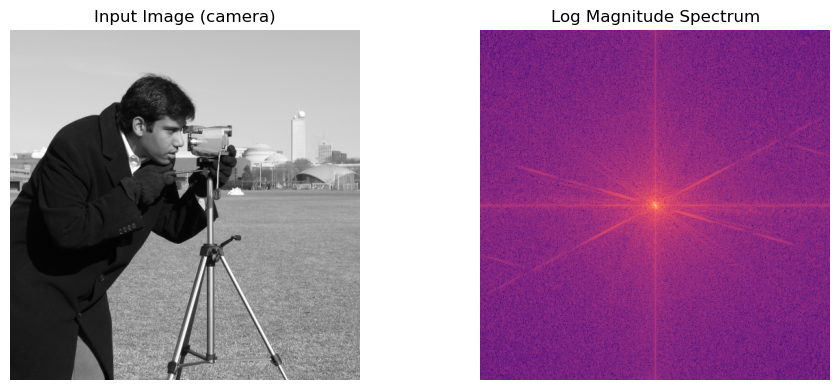

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from numpy.fft import fft2, fftshift

# Load classic image
img = data.camera()  # or data.checkerboard()

# 2D FFT
F = fft2(img)
F_shift = fftshift(F)
mag = np.log(1 + np.abs(F_shift))

# Plot image + spectrum
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Input Image (camera)")
ax[0].axis('off')

ax[1].imshow(mag, cmap='magma')
ax[1].set_title("Log Magnitude Spectrum")
ax[1].axis('off')

plt.tight_layout()
plt.show()

<!-- ## Fourier Transform: What the Axes Mean

- **x-axis:** frequency (Hz); $f=\omega/2\pi$
- **y-axis:** magnitude $|X(f)|$ (energy/amplitude proxy)
- **phase:** $\angle X(f)$ tells time alignment/shift

We use `np.fft.rfft` to compute $X[k]$ and `np.fft.rfftfreq` to map bins to Hz. -->

## Sampling and Nyquist Reminder

- Sampling is taking snapshots in time; the rate of snapshots limits the fastest wiggle you can capture.
- Anything above Nyquist “folds back” into lower frequencies (aliasing), creating false peaks.
- Longer recordings give finer frequency spacing, so peaks are sharper and easier to identify.

- **Nyquist frequency:** $f_{Nyquist} = f_s/2$
- Frequencies above Nyquist **alias** to lower frequencies
- **Frequency resolution** depends on total signal duration (longer signal → finer resolution)

Connection to Week 1: proper sampling is critical for clean spectra.

# 2D Fourier for Images + Frequency Filtering

**Key ideas:**

- **Spatial frequency:** how quickly intensity changes across space
- Smooth regions → low frequency
- Edges/textures → high frequency

## 2D Fourier Transform

For an image

$$
I(x, y)
$$

the 2D Fourier transform is

$$
F(u, v) = \sum_{x,y} I(x,y), e^{-i2\pi \left( \frac{ux}{M} + \frac{vy}{N} \right)}
$$


where:

* low frequencies correspond to smooth intensity variations
* high frequencies correspond to edges and texture

<!-- ## 10. Key Takeaway (Slide-worthy)

> The Fourier transform expresses a signal as a weighted sum of rotating complex exponentials, revealing its frequency structure while preserving all information. -->

In the plot below:

- Bright center = DC / average intensity (overall brightness)
- Energy near center = low frequencies → smooth regions, gradual changes
- Energy far from center = high frequencies → edges, fine texture, noise
- Symmetry about center = real‑valued image (conjugate symmetry in frequency)
- Strong horizontal/vertical streaks = dominant edge orientations in the image
- Log magnitude used so both weak and strong frequencies are visible

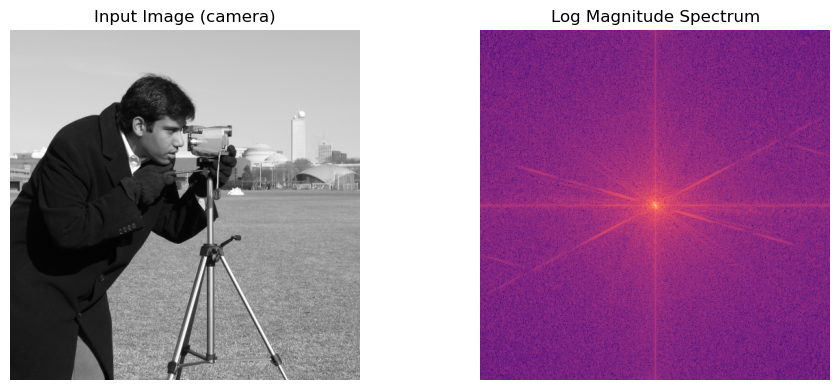

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from numpy.fft import fft2, fftshift

# Load classic image
img = data.camera()  # or data.checkerboard()

# 2D FFT
F = fft2(img)
F_shift = fftshift(F)
mag = np.log(1 + np.abs(F_shift))

# Plot image + spectrum
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Input Image (camera)")
ax[0].axis('off')

ax[1].imshow(mag, cmap='magma')
ax[1].set_title("Log Magnitude Spectrum")
ax[1].axis('off')

plt.tight_layout()
plt.show()

## 2D FFT Intuition

- Apply FFT along rows and columns
- Spectrum is 2D: frequencies in x and y directions
- Visualize with **log magnitude** (otherwise center dominates)
- After `fftshift`, **center = low frequencies**

## Filters in Frequency: Low-Pass vs High-Pass

Images can be filtered in the frequency domain by multiplying the Fourier transform of the image by a mask.

- **Low-pass:** removes high frequencies → blur/smoothing  
- **High-pass:** removes low frequencies → edges/detail emphasis  
- **Cutoff radius** controls how aggressive the filter is  
- **Sharp cutoffs** can introduce ringing artifacts (Gibbs-like ripples)  
- **Shifted FFT:** low frequencies are centered after `fftshift`  
- **Magnitude vs phase:** filtering magnitude changes structure, phase preserves alignment  

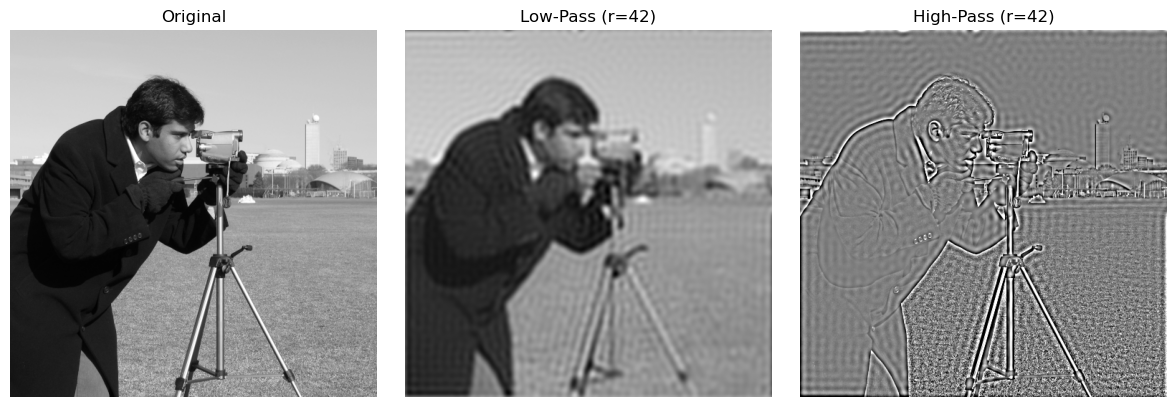

Low-pass → blur (smoothing)
High-pass → edges and details


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def circular_mask(h, w, radius, invert=False):
    Y, X = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    dist = np.sqrt((Y - cy) ** 2 + (X - cx) ** 2)
    mask = dist <= radius
    return ~mask if invert else mask


# Load classic image
img = data.camera()
img_gray = img.astype(np.float32)

# Frequency-domain filtering by masking
F = np.fft.fft2(img_gray)
F_shift = np.fft.fftshift(F)

h, w = img_gray.shape
radius = min(h, w) // 12  # Cutoff radius

# Create masks
lp_mask = circular_mask(h, w, radius, invert=False)  # Keep center
hp_mask = circular_mask(h, w, radius, invert=True)   # Remove center

# Apply masks and inverse FFT
img_lp = np.fft.ifft2(np.fft.ifftshift(F_shift * lp_mask)).real
img_hp = np.fft.ifft2(np.fft.ifftshift(F_shift * hp_mask)).real

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_lp, cmap="gray")
axes[1].set_title(f"Low-Pass (r={radius})")
axes[1].axis("off")

axes[2].imshow(img_hp, cmap="gray", vmin=-50, vmax=50)
axes[2].set_title(f"High-Pass (r={radius})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Low-pass → blur (smoothing)")
print("High-pass → edges and details")

## Why Edges are High Frequency

Edges are “rapid changes,” so they show up as high frequencies, while smooth regions are low frequencies.

Connection to Week 2 spatial filters:

- **Derivative-like kernels** (Sobel, Laplacian) emphasize change → high frequencies
- **Smoothing kernels** (Gaussian, box blur) suppress high frequencies

This is the **frequency view** of what we did in Week 2.

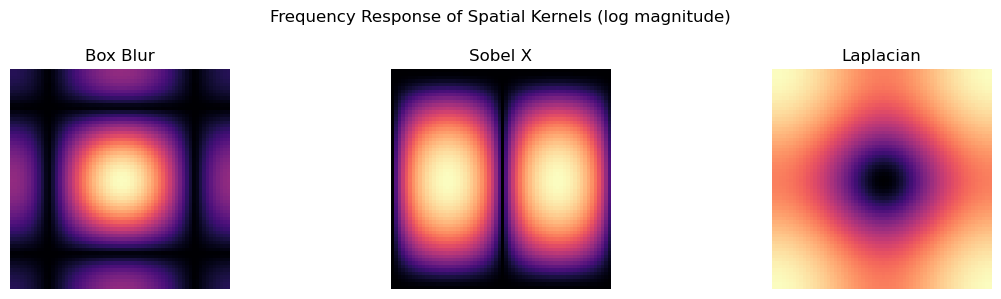

Key message: kernels have 'passbands' too.
CNN filters learn these frequency responses.


In [30]:
# Visualize frequency response of spatial kernels
kernels = {
    "Box Blur": np.ones((3, 3), dtype=np.float32) / 9.0,
    "Sobel X": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32),
    "Laplacian": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32),
}

size = 64
fig, axes = plt.subplots(1, len(kernels), figsize=(12, 3))

for ax, (name, kernel) in zip(axes, kernels.items()):
    # Pad kernel to size x size
    padded = np.zeros((size, size), dtype=np.float32)
    kh, kw = kernel.shape
    padded[:kh, :kw] = kernel
    
    # Compute FFT and shift
    K = np.fft.fftshift(np.fft.fft2(padded))
    mag = np.log1p(np.abs(K))
    
    ax.imshow(mag, cmap="magma")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Frequency Response of Spatial Kernels (log magnitude)")
plt.tight_layout()
plt.show()

print("Key message: kernels have 'passbands' too.")
print("CNN filters learn these frequency responses.")

## Convolution Theorem (Practical)

Convolution in space/time **↔** multiplication in frequency:

$$x(t) * h(t) \leftrightarrow X(\omega)H(\omega)$$

**Why this matters:**
- For large kernels, FFT-based convolution can be **faster**
- "Filtering is filtering" across domains
- Helps debug CNN behavior (what frequencies does a layer pass?)


Convolution is what we do when we “slide a filter over a signal/image.”  
In the frequency domain, that same operation becomes simple **multiplication**:

- Instead of sliding and summing in time/space, you multiply spectra.  
- This makes it easier to **predict what a filter does**:
  - Low‑pass filters remove high frequencies → blur  
  - High‑pass filters remove low frequencies → edges  
- It can also be **faster** for large kernels (FFT‑based convolution).  
- For CNNs, it gives intuition: a layer’s kernel **passes some frequencies and suppresses others**.

So the theorem is not just math—it’s a **practical lens** for understanding filtering and model behavior.

- **Top-left:** original signal and its smoothed (convolved) version in time  
- **Top-right:** the smoothing kernel $h(t)$  
- **Bottom-left:** spectra $|X(f)|$ and $|H(f)|$  
- **Bottom-right:** output spectrum $|Y(f)|$, showing $|Y(f)| = |X(f)H(f)|$  

**Big idea:** Convolution in time/space becomes multiplication in frequency, so smoothing removes high frequencies.

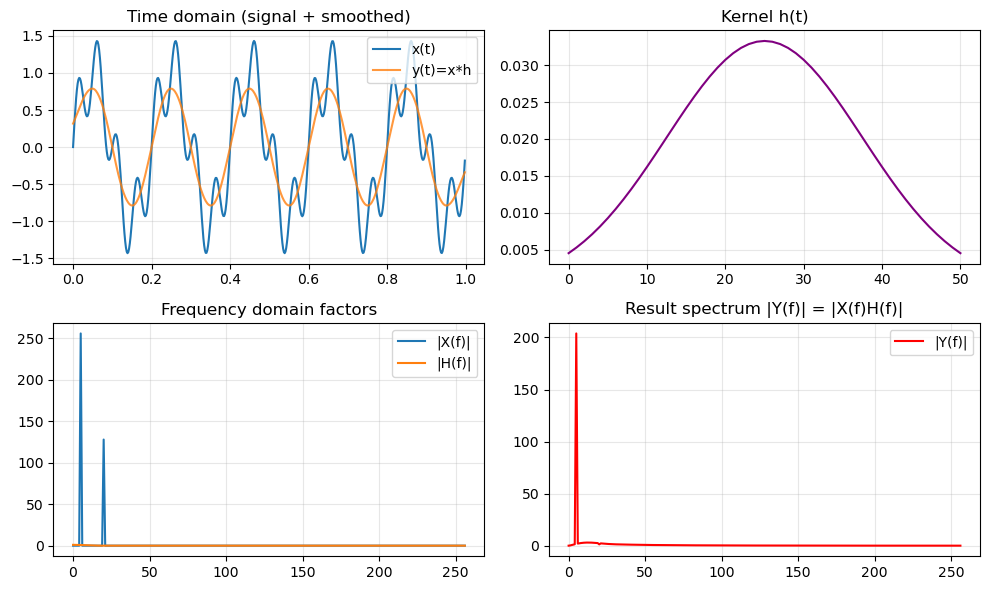

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Signal and kernel
t = np.linspace(0, 1, 512, endpoint=False)
x = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*20*t)
h = np.exp(-0.5*((np.linspace(-2, 2, 51))**2))
h = h / h.sum()

# Convolution (time domain)
y = np.convolve(x, h, mode="same")

# Frequency domain
X = np.fft.rfft(x)
H = np.fft.rfft(h, n=len(x))
Y = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(x), d=1/len(x))

# Plot
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

ax[0,0].plot(t, x, label="x(t)")
ax[0,0].plot(t, y, label="y(t)=x*h", alpha=0.8)
ax[0,0].set_title("Time domain (signal + smoothed)")
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

ax[0,1].plot(h, color="purple")
ax[0,1].set_title("Kernel h(t)")
ax[0,1].grid(alpha=0.3)

ax[1,0].plot(freqs, np.abs(X), label="|X(f)|")
ax[1,0].plot(freqs, np.abs(H), label="|H(f)|")
ax[1,0].set_title("Frequency domain factors")
ax[1,0].legend()
ax[1,0].grid(alpha=0.3)

ax[1,1].plot(freqs, np.abs(Y), label="|Y(f)|", color="red")
ax[1,1].set_title("Result spectrum |Y(f)| = |X(f)H(f)|")
ax[1,1].legend()
ax[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Quick Application Examples

Frequency-domain filtering enables:

- **Periodic noise removal** (notch filter at specific frequencies)
- **High-boost filtering** (sharpening by amplifying high frequencies)
- **Texture analysis** (energy in frequency bands)

# STFT, Spectrograms, Mel Scale

**Key ideas:**

- Plain FFT assumes signal is **stationary** over the window
- Speech/music are **time-varying** → need time–frequency representation
- **STFT** = short-time Fourier transform → spectrogram

## STFT Concept

- Take **short windows**, compute FFT for each window
- **Stack spectra over time** → spectrogram
- **Parameters:**
  - `window_length` (or `n_fft`): size of each window
  - `hop_length`: step size between windows
  - `window_function`: Hann, Hamming, etc. (reduce spectral leakage)
  - `nperseg`: number of points in each segment

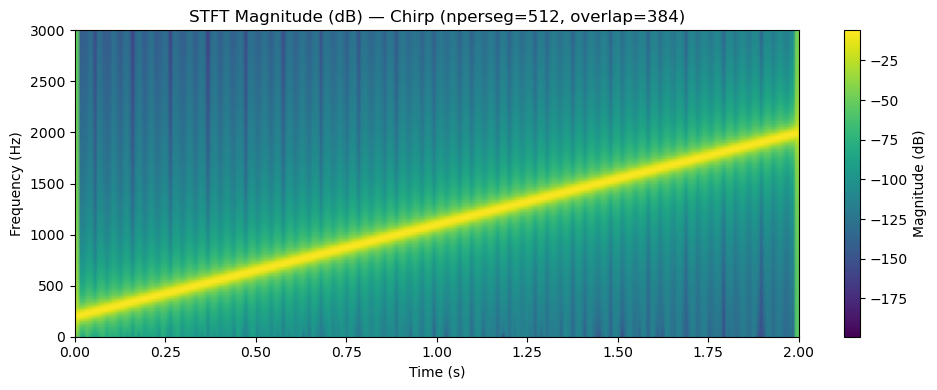

Chirp shows a diagonal ridge: frequency increases over time.


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

import IPython.display as ipd

# STFT on a synthetic chirp (frequency sweeps upward)
sr = 16000
duration = 2.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# Generate chirp
x_chirp = signal.chirp(t, f0=200, f1=2000, t1=duration, method="linear")

# Compute STFT
nperseg = 512
noverlap = 384
f, tt, Zxx = signal.stft(x_chirp, fs=sr, nperseg=nperseg, noverlap=noverlap, window="hann")
S = np.abs(Zxx)
S_db = 20 * np.log10(S + 1e-10)

# Plot spectrogram
plt.figure(figsize=(10, 4))
plt.pcolormesh(tt, f, S_db, shading="gouraud", cmap="viridis")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title(f"STFT Magnitude (dB) — Chirp (nperseg={nperseg}, overlap={noverlap})")
plt.ylim(0, 3000)
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()

print("Chirp shows a diagonal ridge: frequency increases over time.")

# play the chirp
ipd.Audio(x_chirp, rate=sr)

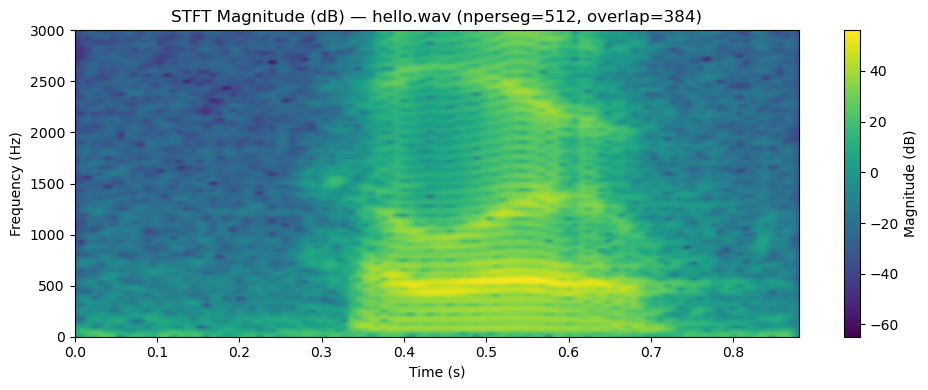

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import IPython.display as ipd

# Load audio
sr, x = wavfile.read("hello.wav")

# Convert to float and mono if needed
if x.ndim > 1:
    x = x.mean(axis=1)
x = x.astype(np.float32)
if x.dtype.kind in "iu":
    x /= np.iinfo(x.dtype).max

# Compute STFT
nperseg = 512
noverlap = 384
f, tt, Zxx = signal.stft(x, fs=sr, nperseg=nperseg, noverlap=noverlap, window="hann")
S = np.abs(Zxx)
S_db = 20 * np.log10(S + 1e-10)

# Plot spectrogram
plt.figure(figsize=(10, 4))
plt.pcolormesh(tt, f, S_db, shading="gouraud", cmap="viridis")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title(f"STFT Magnitude (dB) — hello.wav (nperseg={nperseg}, overlap={noverlap})")
plt.ylim(0, 3000)
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()

# Play audio
ipd.Audio(x, rate=sr)

## Window Length Tradeoff

- **Shorter window:** better **time resolution**, worse **frequency resolution**
- **Longer window:** better **frequency resolution**, worse **time resolution**
- So it’s the trade‑off between when vs which frequency you can distinguish.

This is the **uncertainty principle** for time-frequency analysis.

`nperseg` is the window length (number of samples) used for each STFT frame.

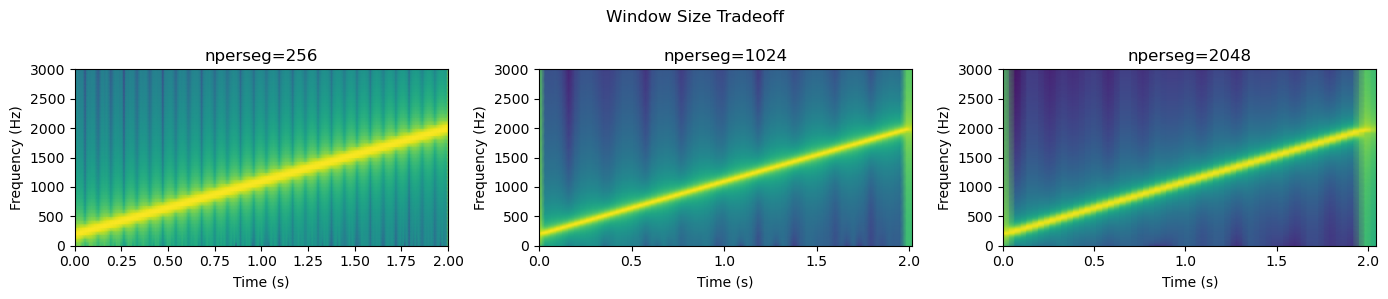

Left: better time resolution (shorter window)
Right: better frequency resolution (longer window)


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Compare different window sizes
window_sizes = [256, 1024, 2048]

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, nperseg in zip(axes, window_sizes):
    noverlap = nperseg // 2
    f, tt, Zxx = signal.stft(x_chirp, fs=sr, nperseg=nperseg, noverlap=noverlap, window="hann")
    S = np.abs(Zxx)
    S_db = 20 * np.log10(S + 1e-10)

    ax.pcolormesh(tt, f, S_db, shading="gouraud", cmap="viridis")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"nperseg={nperseg}")
    ax.set_ylim(0, 3000)

plt.suptitle("Window Size Tradeoff")
plt.tight_layout()
plt.show()

print("Left: better time resolution (shorter window)")
print("Right: better frequency resolution (longer window)")

## Log Spectrograms and Dynamic Range

- Magnitude spans **huge ranges** → use log or **decibel (dB) scale**
- Connection to Week 1: dynamic range and quantization
- Common scaling: `10 * log10(S)` or `librosa.power_to_db`

## Mel Scale Intuition

- Human pitch perception is **log‑like**, not linear: we hear equal *ratios* more than equal *differences*.  
- The **mel filterbank** warps frequency to match this perception.  
- **Low frequencies get more resolution** (important for speech formants).
  - Speech formants are the resonant frequencies of the vocal tract.
- **High frequencies are compressed** (less perceptual detail).  
- This reduces dimensionality while keeping what humans hear as important.  
- Common in **speech/audio ML**: ASR, speaker ID, music tagging.  
- **Pipeline:** waveform → STFT → power spectrum → mel filters → log (dB).  

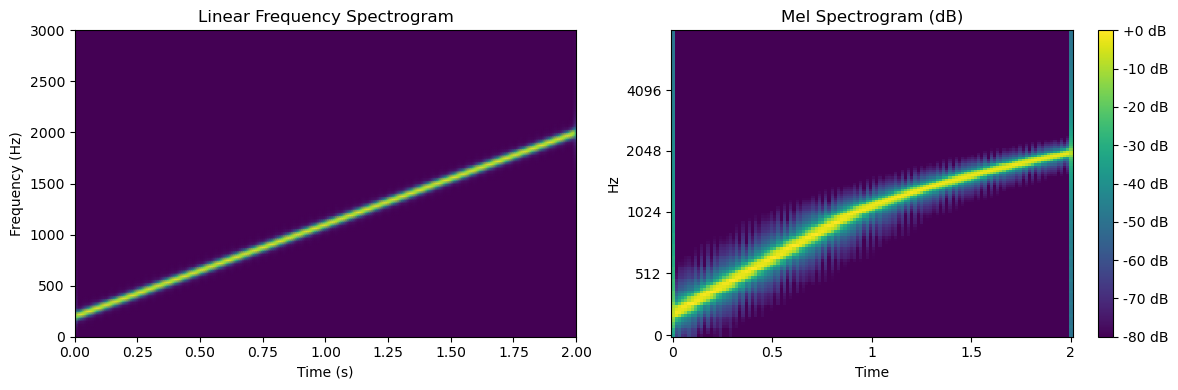

Mel scale: more resolution at low frequencies (human-like pitch perception).


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import librosa.display


# STFT on a synthetic chirp (frequency sweeps upward)
sr = 16000
duration = 2.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# Generate chirp
x_chirp = signal.chirp(t, f0=200, f1=2000, t1=duration, method="linear")

# Mel spectrogram demo (assumes x_chirp and sr already defined)
S_mel = librosa.feature.melspectrogram(
    y=x_chirp, sr=sr, n_fft=512, hop_length=256, n_mels=128
)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear frequency STFT
f, tt, Zxx = signal.stft(x_chirp, fs=sr, nperseg=512, noverlap=384)
S = np.abs(Zxx)
axes[0].pcolormesh(tt, f, np.log1p(S), shading="gouraud", cmap="viridis")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Linear Frequency Spectrogram")
axes[0].set_ylim(0, 3000)

# Mel spectrogram
img = librosa.display.specshow(
    S_mel_db, sr=sr, hop_length=256, x_axis="time", y_axis="mel",
    ax=axes[1], cmap="viridis"
)
axes[1].set_title("Mel Spectrogram (dB)")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

print("Mel scale: more resolution at low frequencies (human-like pitch perception).")

<!-- ## (Optional) MFCCs: Classic Engineered Audio Feature

- **MFCCs** = Mel-Frequency Cepstral Coefficients
- Compress mel log spectra with **DCT** (Discrete Cosine Transform)
- Used heavily in **classic speech pipelines** (pre-deep-learning era)
- Still useful for **small data** or **interpretability** -->

# Feature Engineering

**Key question:** What is a "feature"?

- Feature = a **numeric summary** of raw data that helps a model
- Examples: edges, texture descriptors, spectral peaks, MFCCs

## Hand-Crafted vs Learned Representations

| **Hand-Crafted Features** | **Learned Features (Deep Learning)** |
|---|---|
| Interpretable | Harder to interpret |
| Fast to compute | Requires training |
| Works with small data | Data-hungry |
| Brittle (needs domain expertise) | Flexible (learns from data) |
| Examples: HOG, SIFT, MFCCs | Examples: CNN features, transformer embeddings |

**Why are hand-crafted features still important?**

- They provide **intuition** for what deep models learn
- Strong **baselines** for debugging
- Useful when **data is scarce**

## Image Features: Gradients, Histograms, HOG

**Classic hand-crafted image features:**

- **Gradient magnitude/orientation** (edges)
- **Histogram of Oriented Gradients (HOG):** counts of edge directions in patches
- **SIFT/SURF:** scale-invariant keypoint descriptors

and many more (e.g., LBP, Gabor filters, color histograms, edge density).

These were state-of-the-art for **classification/detection** before deep learning.

## Audio Features: Spectral Centroid, Bandwidth, Rolloff

**Classic hand-crafted audio features:**

- **Spectral centroid:** "brightness" (center of mass of spectrum)
- **Spectral bandwidth:** spread of energy
- **Spectral rolloff:** frequency below which X% of energy lies
- **Energy/RMS, zero-crossing rate**
- **Mel spectrogram features (MFCCs)**

and many more (e.g., spectral flux, spectral flatness, chroma, pitch, MFCC deltas)

These compress waveforms into **low-dimensional summaries** for downstream ML.

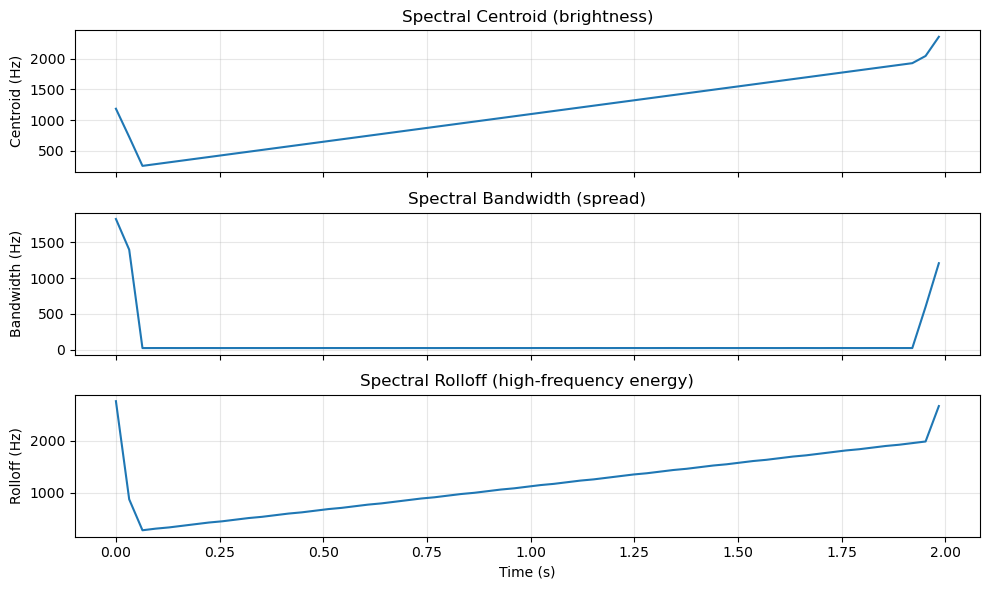

Features track the chirp's increasing frequency over time.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display



# Compute small feature table from audio (assumes x_chirp and sr defined)
centroid = librosa.feature.spectral_centroid(y=x_chirp, sr=sr, hop_length=512)[0]
bandwidth = librosa.feature.spectral_bandwidth(y=x_chirp, sr=sr, hop_length=512)[0]
rolloff = librosa.feature.spectral_rolloff(y=x_chirp, sr=sr, hop_length=512)[0]

frames = np.arange(len(centroid))
times = librosa.frames_to_time(frames, sr=sr, hop_length=512)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

axes[0].plot(times, centroid)
axes[0].set_ylabel("Centroid (Hz)")
axes[0].set_title("Spectral Centroid (brightness)")
axes[0].grid(alpha=0.3)

axes[1].plot(times, bandwidth)
axes[1].set_ylabel("Bandwidth (Hz)")
axes[1].set_title("Spectral Bandwidth (spread)")
axes[1].grid(alpha=0.3)

axes[2].plot(times, rolloff)
axes[2].set_ylabel("Rolloff (Hz)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Spectral Rolloff (high-frequency energy)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Features track the chirp's increasing frequency over time.")

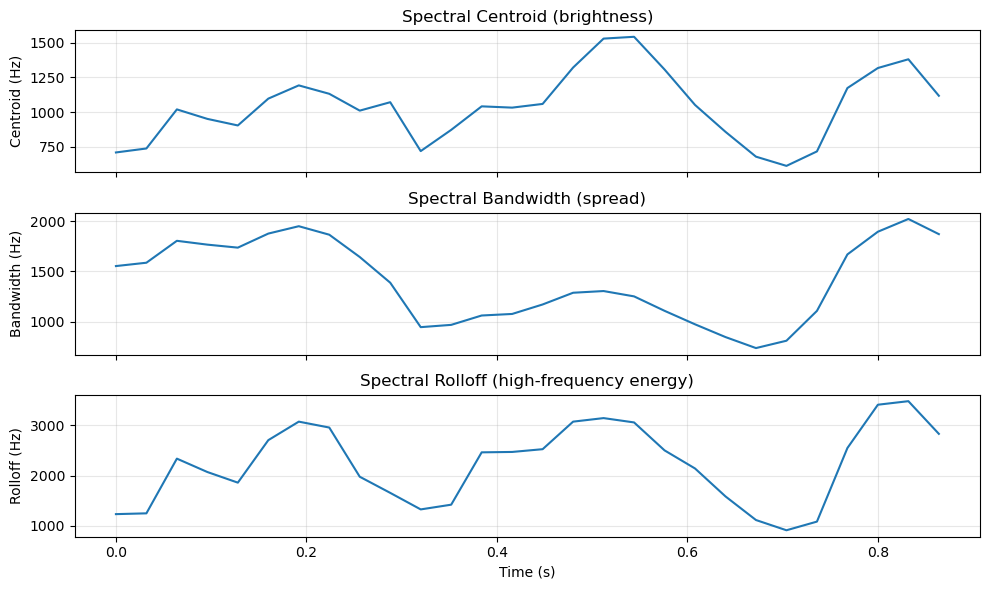

Features computed from hello.wav


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Try to use hello.wav; fall back to existing x_chirp/sr if not found
hello_path = "hello.wav"
if os.path.exists(hello_path):
    x, sr = librosa.load(hello_path, sr=None)  # keep original sample rate
else:
    x = x_chirp  # assumes x_chirp and sr already defined
    # sr already defined in your notebook

centroid = librosa.feature.spectral_centroid(y=x, sr=sr, hop_length=512)[0]
bandwidth = librosa.feature.spectral_bandwidth(y=x, sr=sr, hop_length=512)[0]
rolloff = librosa.feature.spectral_rolloff(y=x, sr=sr, hop_length=512)[0]

frames = np.arange(len(centroid))
times = librosa.frames_to_time(frames, sr=sr, hop_length=512)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

axes[0].plot(times, centroid)
axes[0].set_ylabel("Centroid (Hz)")
axes[0].set_title("Spectral Centroid (brightness)")
axes[0].grid(alpha=0.3)

axes[1].plot(times, bandwidth)
axes[1].set_ylabel("Bandwidth (Hz)")
axes[1].set_title("Spectral Bandwidth (spread)")
axes[1].grid(alpha=0.3)

axes[2].plot(times, rolloff)
axes[2].set_ylabel("Rolloff (Hz)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Spectral Rolloff (high-frequency energy)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Features computed from hello.wav" if os.path.exists(hello_path) else "Features computed from chirp")

## How Engineered Features Connect to CNNs

- **CNN layers** learn filters that behave like **feature extractors**
- **Early layers** often resemble **edge detectors** / Gabor-like filters
- **Spectrogram + CNN** = learned pattern recognition in time–frequency domain

**Key insight:** Deep learning automates feature engineering, but understanding classic features helps debug and interpret models.

## Quiz 3 Study Guide

**Topics to review:**

- Fourier Transform intuition (time ↔ frequency, magnitude vs phase)
- Euler’s formula / complex exponentials as rotating vectors
- FFT peaks: fundamentals, harmonics, and why multiple peaks appear
- Winding machine idea: how a frequency “matches” a signal
- 2D FFT interpretation (low vs high frequencies in images)
- Frequency-domain filtering (low-pass / high-pass effects, artifacts)
- Spectrograms (STFT): axes, window size tradeoff (time vs freq resolution)
- Mel scale: why and what it compresses
- Feature engineering examples (audio: centroid/bandwidth/rolloff; image: HOG/SIFT/MFCCs)
- Nyquist frequency + aliasing (what goes wrong above Nyquist)

**Example questions:**

- A spectrum has strong peaks at 440 Hz and 880 Hz. What does that imply about the signal?
- Why can two signals with the same magnitude spectrum sound different?
- In a shifted 2D FFT image, where are low frequencies and what do they represent?
- What visual change do you expect after applying a high-pass filter to an image?
- If you increase `nperseg`, what happens to time vs frequency resolution in a spectrogram?
- What does the mel scale do to frequency spacing, and why is it useful?
- Define spectral centroid in one sentence and explain what a higher value indicates.
- What is aliasing, and how does it relate to the Nyquist frequency?

## Key Takeaways

1. **Frequency domain is a lens:** it explains blur, edges, and audio structure
2. **STFT gives time–frequency views** for non-stationary signals (speech, music)
3. **Features: engineered vs learned** — tradeoffs, and why both matter

**Next week:** CNNs for vision (Week 4) — connecting filters to learned features